<h1> Tabu Search </h1>

Main idea

Tabu Search introduces a completely new concept:</br>
The algorithm uses memory instead of randomness.</br>
This distinguishes it from the two previous algorithms.

Current Solution

        ↓

Generate Neighbors

        ↓

Remove Tabu Moves

        ↓

Choose Best Remaining

        ↓

Update Memory

Tabu List helps:

Avoid repetitive moves.</br>
Avoid cycles.</br>
Search for more space.

Important Parameters of Tabu Search

1) Tabu Tenure (Duration of the ban.) </br>
2) Neighborhood Size </br>
3) Stopping Criteria

The Tabu List acts as a form of short-term memory.

Its purpose is to prevent:

Immediate reversal</br>
Cycling</br>
Repeating previously visited paths

Simulated Annealing escapes local optima by allowing moves that worsen the solution, whereas Tabu Search manages the process using a memory of past paths.

A very important summary of Classical Local Search

We now have three different philosophies:


| Algorithm           | Main Idea            | Exploration Mechanism |
| ------------------- | -------------------- | --------------------- |
| Hill Climbing       | Greedy improvement   | Doesn't have it       |
| Simulated Annealing | Accept worse moves   | Probability           |
| Tabu Search         | Avoid previous moves | Memory                |


Unlike Hill Climbing and SA, we must choose a discrete problem, because the concept of a Tabu List is clearer when applied to moves and states.

<h3> Step 1: Binary Optimization Problem </h3>

Why is this problem suitable?

Because we can clearly see all the components of Tabu search:

| Concept    | In our problem |
| ---------- | -------------- |
| State | Binary string |
| Neighbor | Flipping a single |
| Move | The index that was changed |
| Objective | Number of 1s |
| Tabu List | Recently modified indices |

Neighbor Generation

There is an important point regarding Tabu Search:

We do not simply generate a neighbor; we must also know what the move was.

This is because Tabu operates on the move itself.

In [9]:
import matplotlib.pyplot as plt

from src.tabu_search import (
    binary_objective,
    get_neighbors,
    tabu_search,
    tabu_search_with_history,
)

In [2]:
state = [
    1,0,1,0
]

get_neighbors(state)

[([0, 0, 1, 0], 0), ([1, 1, 1, 0], 1), ([1, 0, 0, 0], 2), ([1, 0, 1, 1], 3)]

<h3> Step 2: Now, the main algorithm. </h3>

In [3]:
initial_state = [
    1,0,0,1,0,0,1,0,0,1
]

solution = tabu_search(
    binary_objective,
    initial_state,
    get_neighbors,
    iterations=50,
    tabu_tenure=3,
)

In [4]:
print(solution)

print(
    binary_objective(solution)
)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
10


<h3> Step 3: Examining the Effect of Tabu Tenure </h3>

In [5]:
for tenure in [1,3,5,10]:
    solution = tabu_search(
        binary_objective,
        initial_state,
        get_neighbors,
        iterations=50,
        tabu_tenure=tenure,
    )
    print(
        "Tabu Tenure:",
        tenure,
        "Fitness:",
        binary_objective(solution),
        "Solution:",
        solution,
    )

Tabu Tenure: 1 Fitness: 10 Solution: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tabu Tenure: 3 Fitness: 10 Solution: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tabu Tenure: 5 Fitness: 10 Solution: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Tabu Tenure: 10 Fitness: 10 Solution: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


<h3> Step 4: Adding History </h3>

In [6]:
solution, history = tabu_search_with_history(
    binary_objective,
    initial_state,
    get_neighbors,
    iterations=50,
    tabu_tenure=3,
)

In [7]:
print(solution)

print(
    binary_objective(solution)
)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
10


In [8]:
history

[{'iteration': 0, 'current_value': 5, 'best_value': 5, 'tabu_list': [1]},
 {'iteration': 1, 'current_value': 6, 'best_value': 6, 'tabu_list': [1, 2]},
 {'iteration': 2, 'current_value': 7, 'best_value': 7, 'tabu_list': [1, 2, 4]},
 {'iteration': 3, 'current_value': 8, 'best_value': 8, 'tabu_list': [2, 4, 5]},
 {'iteration': 4, 'current_value': 9, 'best_value': 9, 'tabu_list': [4, 5, 7]},
 {'iteration': 5,
  'current_value': 10,
  'best_value': 10,
  'tabu_list': [5, 7, 8]},
 {'iteration': 6,
  'current_value': 9,
  'best_value': 10,
  'tabu_list': [7, 8, 0]},
 {'iteration': 7,
  'current_value': 8,
  'best_value': 10,
  'tabu_list': [8, 0, 1]},
 {'iteration': 8,
  'current_value': 7,
  'best_value': 10,
  'tabu_list': [0, 1, 2]},
 {'iteration': 9,
  'current_value': 6,
  'best_value': 10,
  'tabu_list': [1, 2, 3]},
 {'iteration': 10,
  'current_value': 7,
  'best_value': 10,
  'tabu_list': [2, 3, 0]},
 {'iteration': 11,
  'current_value': 8,
  'best_value': 10,
  'tabu_list': [3, 0, 1]

In [10]:
best_values = [
    item["best_value"]
    for item in history
]

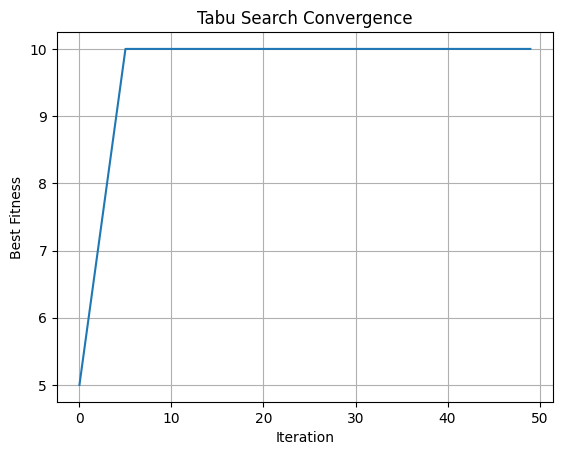

In [11]:
plt.plot(
    best_values
)

plt.xlabel(
    "Iteration"
)

plt.ylabel(
    "Best Fitness"
)

plt.title(
    "Tabu Search Convergence"
)

plt.grid()

plt.show()

Classical Local Search

Hill Climbing</br>
Greedy local improvement</br>
Fast but suffers from local optima</br>
No exploration mechanism

Simulated Annealing</br>
Inspired by physical annealing</br>
Allows worse moves probabilistically</br>
Uses temperature schedule to balance exploration/exploitation

Tabu Search</br>
Memory-based local search</br>
Uses tabu list to avoid cycling</br>
Aspiration criterion allows exceptional moves

| Algorithm           | Main Idea            | Memory | Randomness |
| ------------------- | -------------------- | ------ | ---------- |
| Hill Climbing       | Best neighbor        | No      | Low        |
| Simulated Annealing | Accept worse moves   | No      | High       |
| Tabu Search         | Avoid previous moves | Yes      | Low/Medium |
